# QNP-based SQD implementation for CO$_2$@MOF (gates with zero or small contributions are removed)

This notebook presents a simple Qiskit implementation of the QNP ansatz <br>
https://iopscience.iop.org/article/10.1088/1367-2630/ac2cb3/meta <br>
The specific case considered here is the (14,14) active space of CO$_2$ adsorbed in MOF. The simulation involves 28 qubits and 4 layers depth. This is not sufficient to achieve chemical accuracy within the standard VQE approach but, as shown below, noisy sample-based quantum diagonalization (SQD) can overcome these limitations.<br> 
To simplify future simulations on harware, the QNP ansatz uses fixed parameters obtained from Quicksilver (the optimization itself could be challenging in the presence of noise). Additionally, gates that do not or weakly contribute to the final results are removed. In this way the number of gates is decreased to 40 from the 104 of the full 4-layer QNP ansatz. <br>

Set up quantum circuit

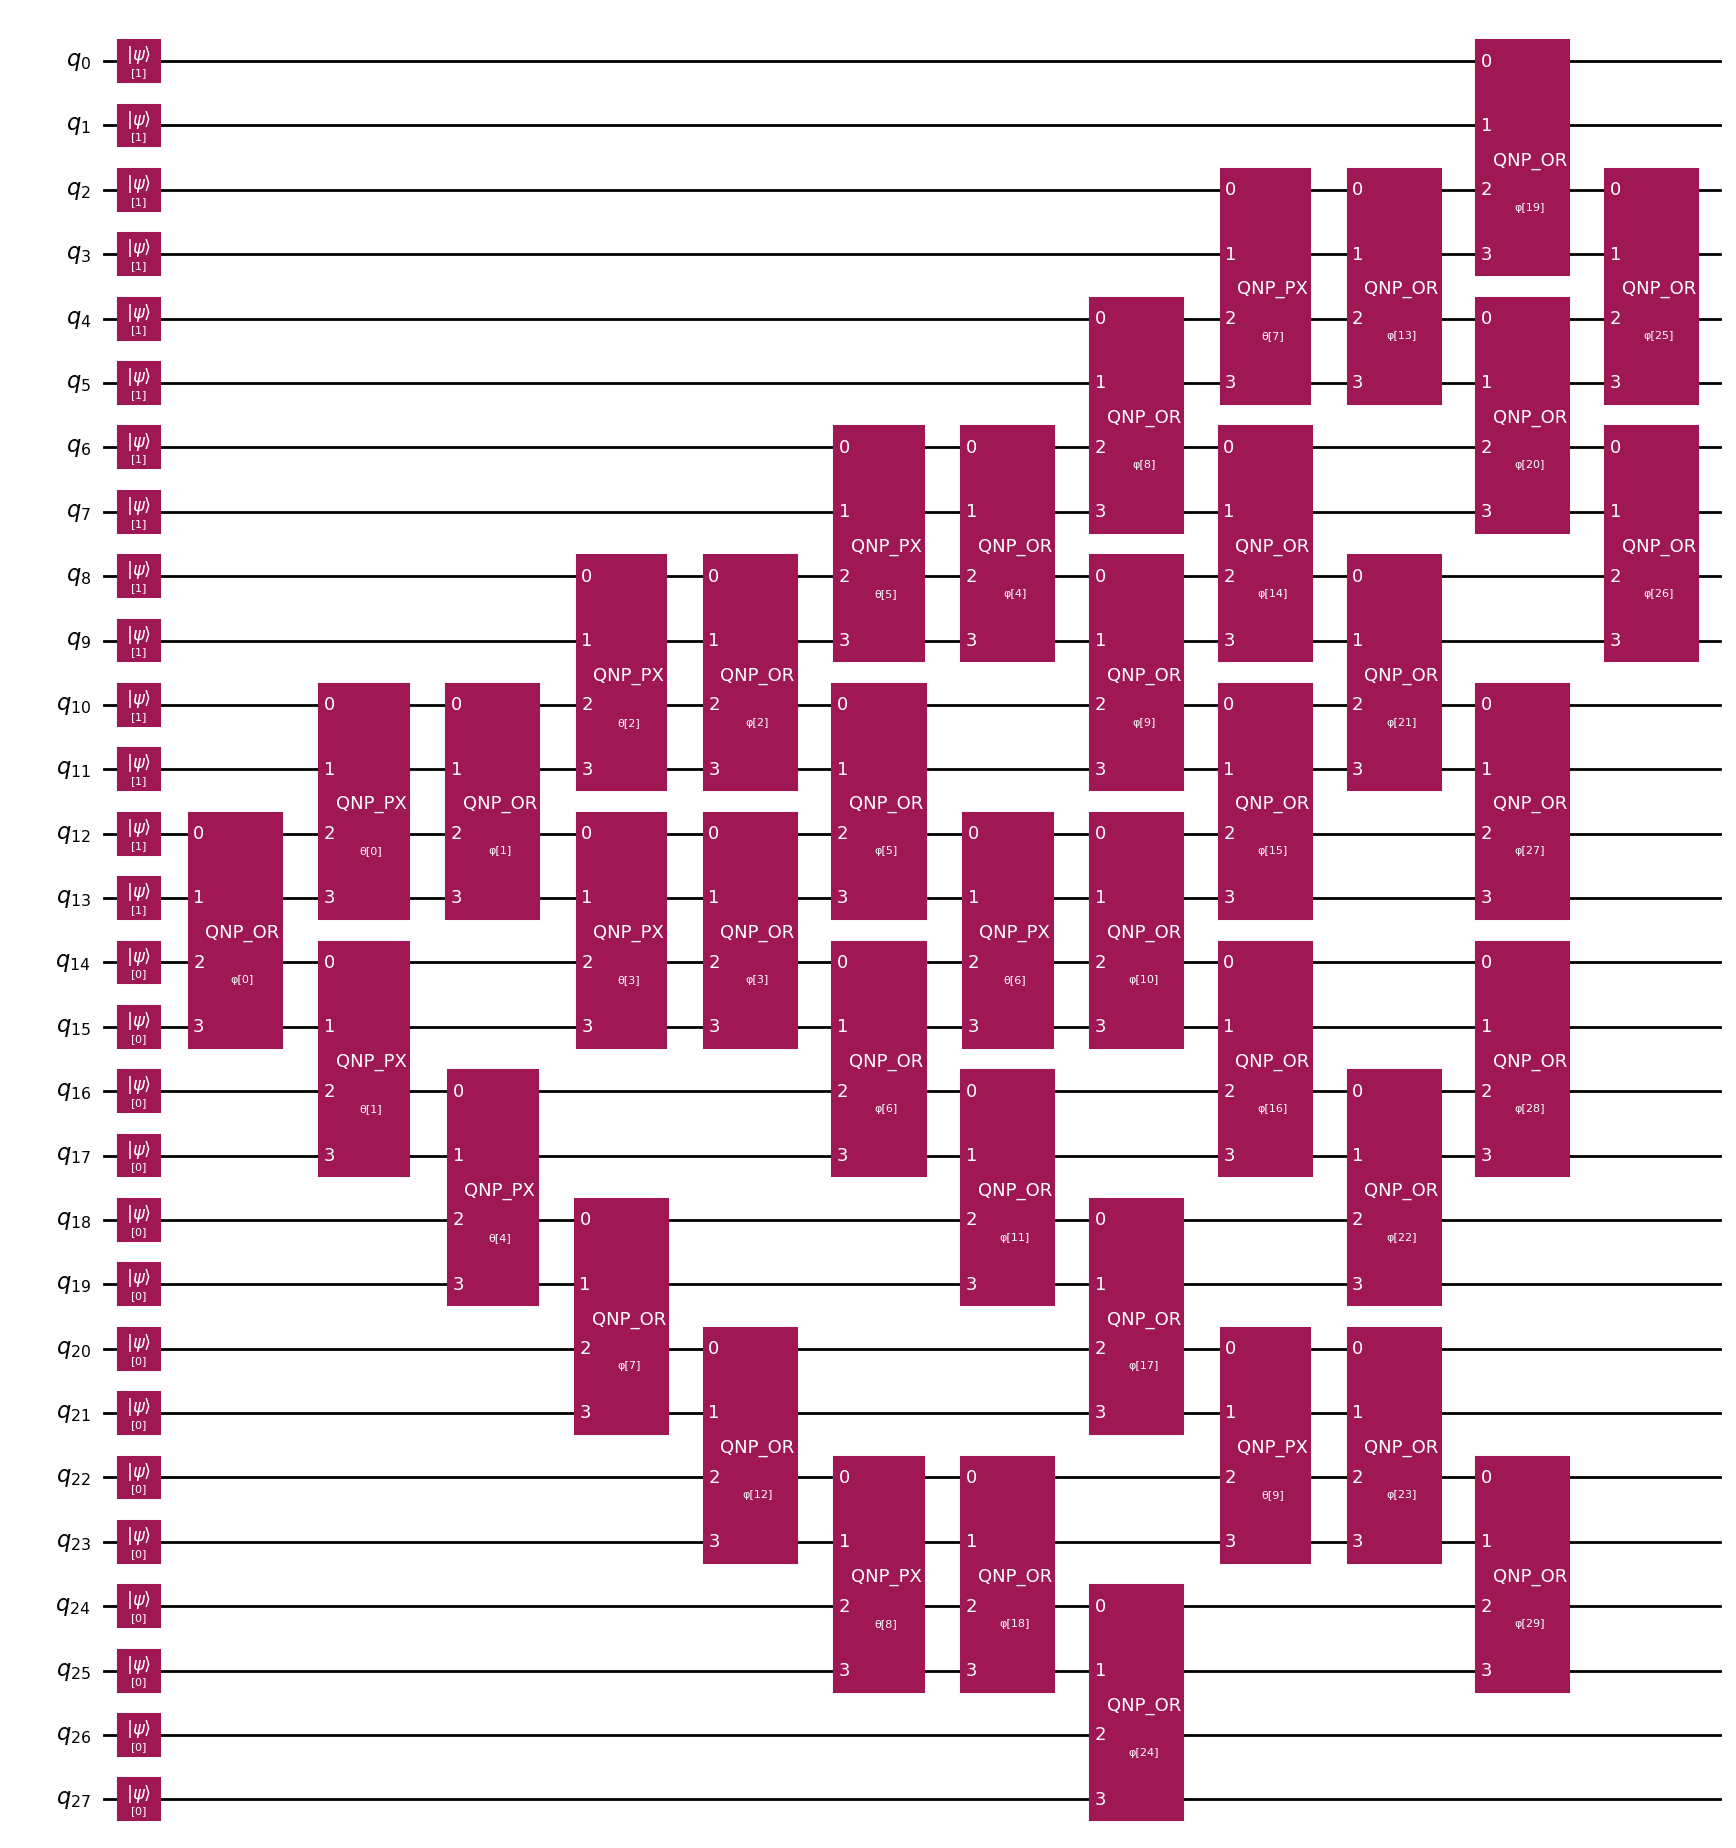

In [1]:
import numpy as np
import sys
sys.path.append('../../../qnp_vqe_qiskit_simulator/qnp_utils')
from qnp_utils import count_QNP_params, initialize_HF
from qnp_utils import QNP_fabric, QNP_PX_GATE, QNP_OR_GATE
from qiskit.circuit import ParameterVector
from qiskit import QuantumCircuit

n_layers = 4
n_qbits = 28
intfile = '../../../fullci_reference_pyscf/singlet/MOFCO2integrals.npz'
integrals = np.load(intfile)
nelec = int(integrals['Nelec'])

#n_theta, n_phi = count_QNP_params(n_qbits, n_layers)
n_theta = 10
n_phi = 30

theta = ParameterVector('θ', n_theta)
phi = ParameterVector('φ', n_phi)

qnp_circ = QuantumCircuit(n_qbits)
initialize_HF(qnp_circ,nelec)

#Some gates do not contribute and should be removed from the ansatz for efficiency
#For this reason we build the QNP ansatz explicitly instead of using QNP_fabric 

#First layer
qnp_circ.append(QNP_OR_GATE(phi[0]), [12, 13, 14, 15])
#qnp_circ.barrier()
qnp_circ.append(QNP_PX_GATE(theta[0]), [10, 11, 12, 13])
qnp_circ.append(QNP_PX_GATE(theta[1]), [14, 15, 16, 17])
qnp_circ.append(QNP_OR_GATE(phi[1]), [10, 11, 12, 13])
#qnp_circ.barrier()
iphi = 2 
itheta = 2

#Second layer
for nq in [8,12,16]:
    qnp_circ.append(QNP_PX_GATE(theta[itheta]), [nq, nq+1, nq+2, nq+3])
    itheta += 1
for nq in [8,12]:
    qnp_circ.append(QNP_OR_GATE(phi[iphi]), [nq, nq+1, nq+2, nq+3])
    iphi += 1
#qnp_circ.barrier()
qnp_circ.append(QNP_PX_GATE(theta[itheta]), [6, 7, 8, 9])
itheta += 1
for nq in [6,10,14,18]:
    qnp_circ.append(QNP_OR_GATE(phi[iphi]), [nq, nq+1, nq+2, nq+3])
    iphi += 1
#qnp_circ.barrier()

#Third layer
qnp_circ.append(QNP_PX_GATE(theta[itheta]), [12, 13, 14, 15])
itheta += 1
for nq in [4,8,12,16,20]:
    qnp_circ.append(QNP_OR_GATE(phi[iphi]), [nq, nq+1, nq+2, nq+3])
    iphi += 1
#qnp_circ.barrier()
qnp_circ.append(QNP_PX_GATE(theta[itheta]), [2, 3, 4, 5])
itheta += 1
qnp_circ.append(QNP_PX_GATE(theta[itheta]), [22, 23, 24, 25])
itheta += 1
for nq in [2,6,10,14,18,22]:
    qnp_circ.append(QNP_OR_GATE(phi[iphi]), [nq, nq+1, nq+2, nq+3])
    iphi += 1
#qnp_circ.barrier()

#Fourth layer
qnp_circ.append(QNP_PX_GATE(theta[itheta]), [20, 21, 22, 23])
for nq in [0,4,8,16,20,24]:
    qnp_circ.append(QNP_OR_GATE(phi[iphi]), [nq, nq+1, nq+2, nq+3])
    iphi += 1
#qnp_circ.barrier()
for nq in [2,6,10,14,22]:
    qnp_circ.append(QNP_OR_GATE(phi[iphi]), [nq, nq+1, nq+2, nq+3])
    iphi += 1

# Draw the main circuit
qnp_circ.draw('mpl')

Set up Hamiltonian 

In [2]:
from qiskit_nature.second_q.hamiltonians import ElectronicEnergy
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit.quantum_info import SparsePauliOp
from qnp_utils import reorder_alphabeta_to_interleaved

#Load the active space integrals defining the Hamiltonian 
H0 = integrals['Ecore']
H1 = integrals['Hact']
H2 = integrals['Iact']

print(f"H0: {H0}")
print(f"H1 type: {type(H1)}, H1 shape {H1.shape}")
print(f"H2 type: {type(H2)}, H2 shape {H2.shape}")

#Setting up the electronic Hamiltonian from H1 and H2 integrals
hamiltonian = ElectronicEnergy.from_raw_integrals(H1, H2)
hamiltonian.nuclear_repulsion_energy = H0 # This is just a constant in the Hamiltonian

#Hamiltonian in second quantization
second_q_H = hamiltonian.second_q_op()

#Fermion to qubit mapping
mapper = JordanWignerMapper()
qubit_jw_H = mapper.map(second_q_H)

#Changing Pauli strings to interleaved order 
pauli_terms = qubit_jw_H.paulis  
coeffs = qubit_jw_H.coeffs
interleaved_pauli = reorder_alphabeta_to_interleaved(pauli_terms)
qubit_jw_H = SparsePauliOp.from_list(list(zip(interleaved_pauli, coeffs)))

H0: 0.0
H1 type: <class 'numpy.ndarray'>, H1 shape (14, 14)
H2 type: <class 'numpy.ndarray'>, H2 shape (14, 14, 14, 14)


Use Qiskit to compute the exact expectation value

Qiskit estimate of ground state energy (exact estimator): -74.46085965826032 Ha
Deviation from reference FCI: 0.245126867998394 Ha
Deviation of Quicksilver (reduced circuit):  0.24513463120143797 Ha
Deviation of Quicksilver (full circuit):     0.23061689112084593 Ha


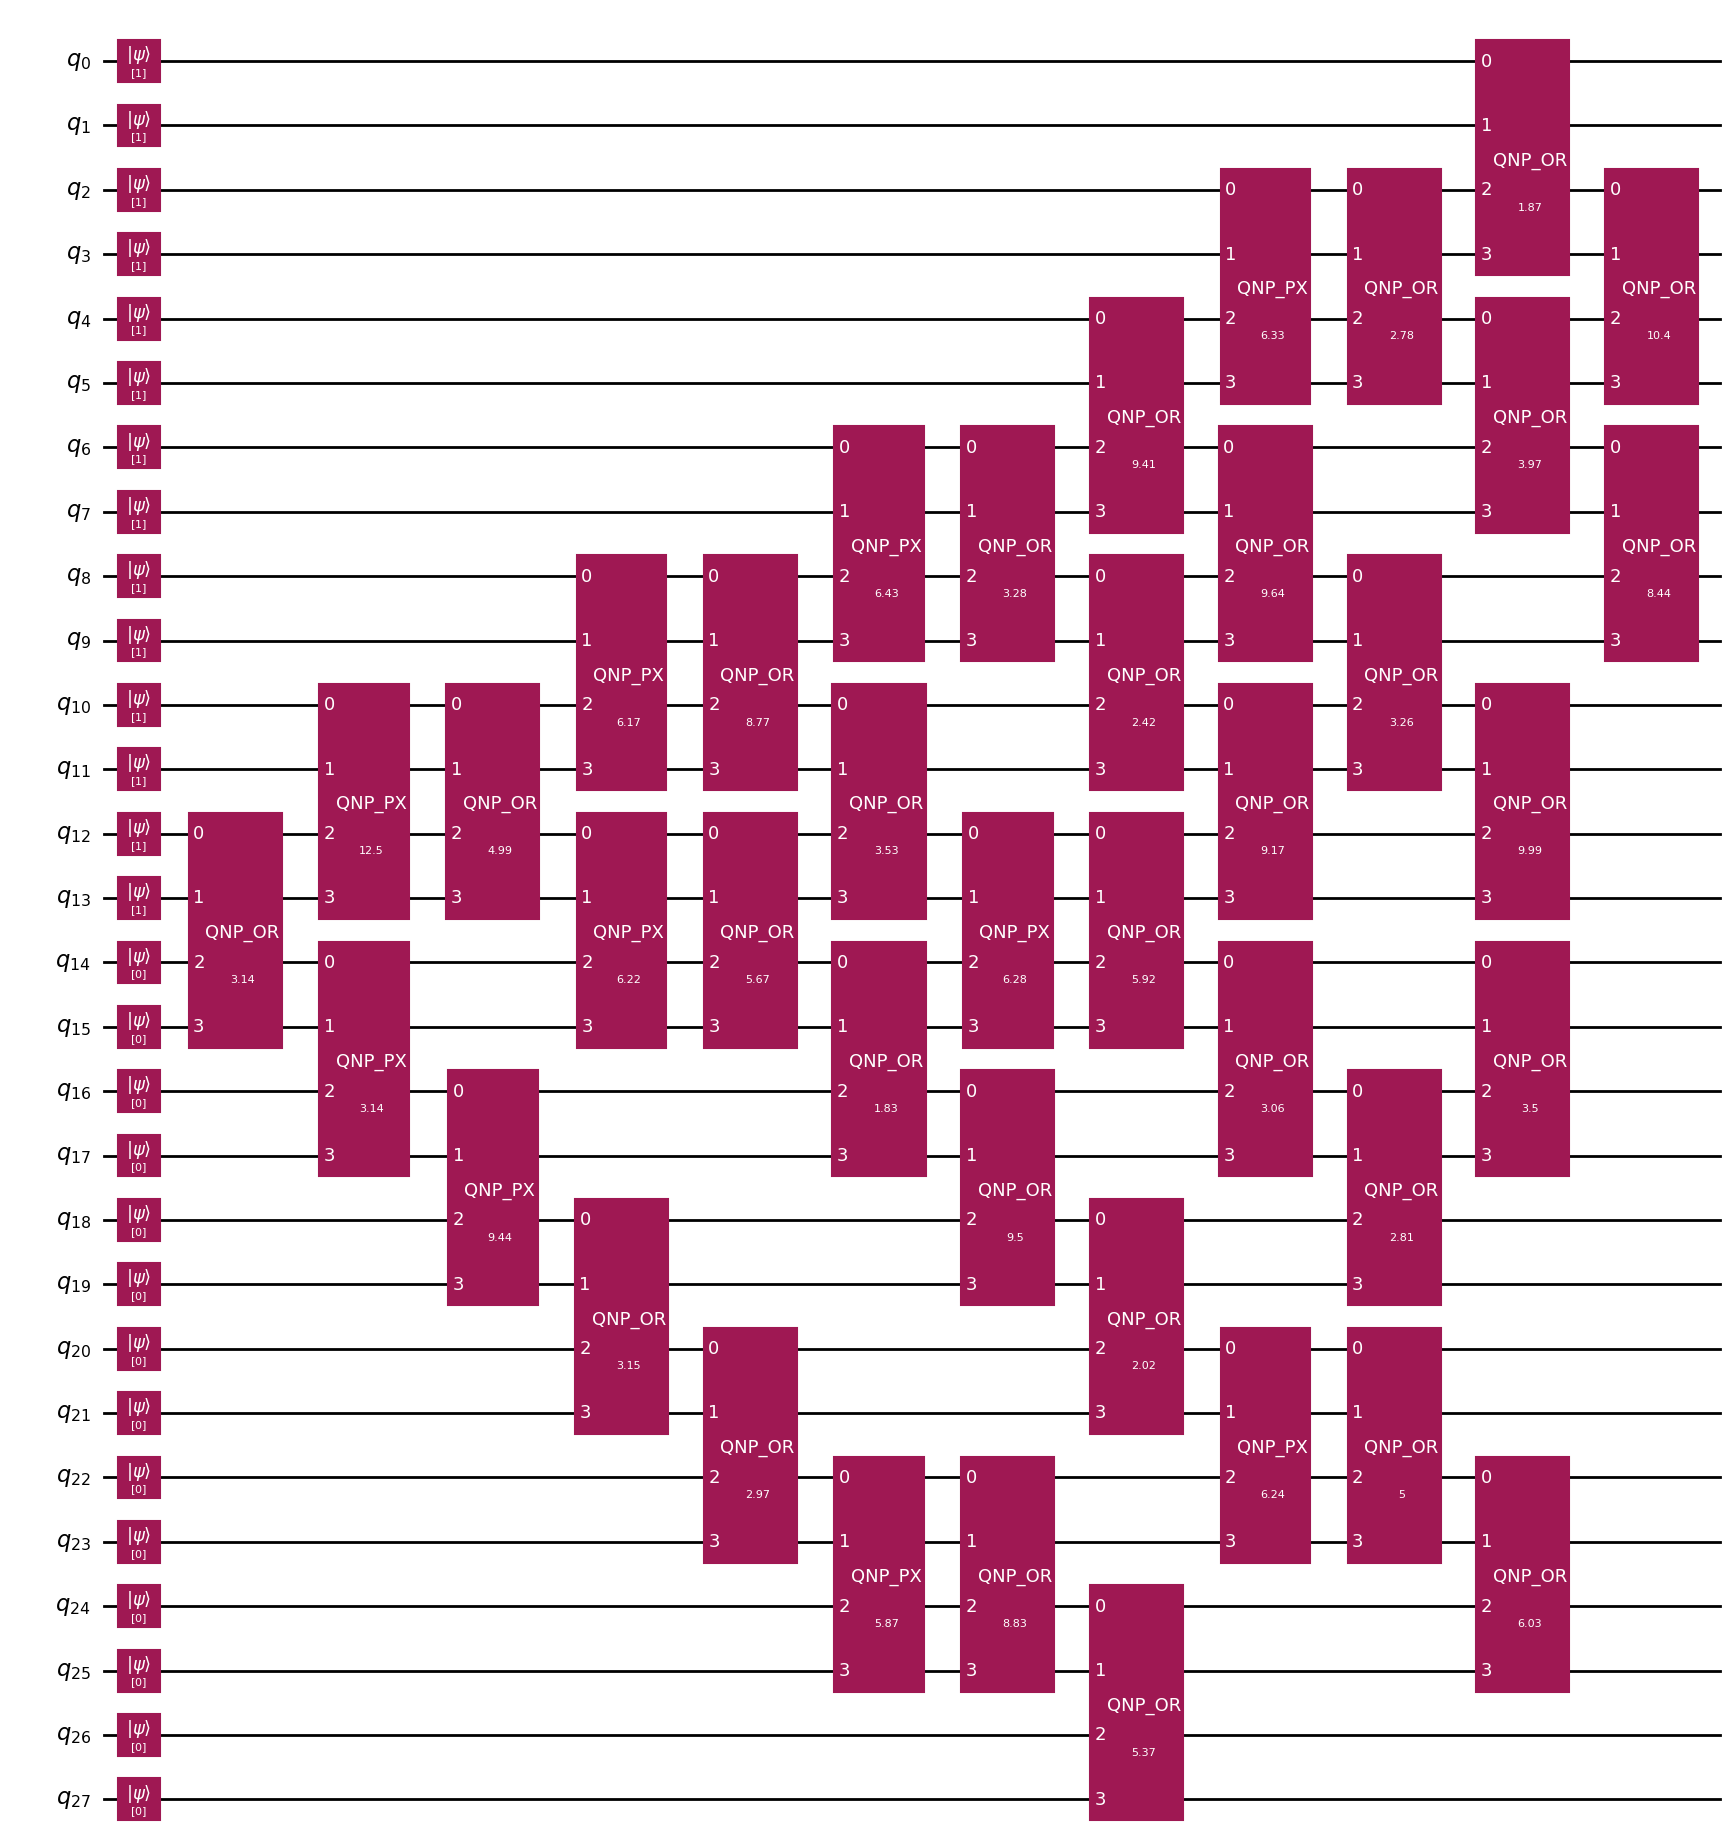

In [3]:
from qiskit.primitives import StatevectorEstimator
from qiskit.circuit import Parameter, ParameterVector
from qnp_utils import assign_parameters_from_file

#Reference FCI value
E_FCI = integrals['Efci']

exact_estimator = StatevectorEstimator()

parfile='optimized_params.txt'
with open(parfile, 'r') as f:
    opt_params = 2.0*np.array(list(map(float, f.read().strip().split(' '))))

param_values = {}

#First layer
param_values.update({phi[0]: opt_params[10]})
param_values.update({theta[0]: opt_params[16]})
param_values.update({theta[1]: opt_params[17]})
param_values.update({phi[1]: opt_params[22]})

#Second layer
param_values.update({theta[2]: opt_params[28]}) 
param_values.update({theta[3]: opt_params[29]}) 
param_values.update({theta[4]: opt_params[30]})
param_values.update({phi[2]: opt_params[35]}) 
param_values.update({phi[3]: opt_params[36]}) 

param_values.update({theta[5]: opt_params[41]})
param_values.update({phi[4]: opt_params[47]}) 
param_values.update({phi[5]: opt_params[48]}) 
param_values.update({phi[6]: opt_params[49]})
param_values.update({phi[7]: opt_params[50]})

#Third layer
param_values.update({theta[6]: opt_params[55]})
param_values.update({phi[8]: opt_params[60]}) 
param_values.update({phi[9]: opt_params[61]})
param_values.update({phi[10]: opt_params[62]}) 
param_values.update({phi[11]: opt_params[63]})
param_values.update({phi[12]: opt_params[64]})

param_values.update({theta[7]: opt_params[66]})
param_values.update({theta[8]: opt_params[71]})
param_values.update({phi[13]: opt_params[72]}) 
param_values.update({phi[14]: opt_params[73]})
param_values.update({phi[15]: opt_params[74]})
param_values.update({phi[16]: opt_params[75]})
param_values.update({phi[17]: opt_params[76]})
param_values.update({phi[18]: opt_params[77]})

#Fourth layer
param_values.update({theta[9]: opt_params[83]})
param_values.update({phi[19]: opt_params[85]}) 
param_values.update({phi[20]: opt_params[86]})
param_values.update({phi[21]: opt_params[87]})
param_values.update({phi[22]: opt_params[89]})
param_values.update({phi[23]: opt_params[90]})
param_values.update({phi[24]: opt_params[91]})

param_values.update({phi[25]: opt_params[98]}) 
param_values.update({phi[26]: opt_params[99]})
param_values.update({phi[27]: opt_params[100]})
param_values.update({phi[28]: opt_params[101]})
param_values.update({phi[29]: opt_params[103]})

qnp_fix_param = qnp_circ.assign_parameters(param_values)

results = exact_estimator.run([(qnp_fix_param, qubit_jw_H)]).result()
qiskit_exact_GSenergy=results[0].data.evs+H0

print(f"Qiskit estimate of ground state energy (exact estimator): {qiskit_exact_GSenergy} Ha")
print(f"Deviation from reference FCI: {qiskit_exact_GSenergy-E_FCI} Ha")
print("Deviation of Quicksilver (reduced circuit):  0.24513463120143797 Ha")
print("Deviation of Quicksilver (full circuit):     0.23061689112084593 Ha")
qnp_fix_param.draw('mpl')

### SQD on hardware

The credentials of QC Ware's account have been removed (token="...", instance="...").

In order to obtain an optimally transpiled quantum circuit for the hardware simulation, the transpilation is applied 2000 times and the quantum circuit with the lowest depth is selected. To ensure reproducibility, the transpiled circuit is saved to a file. To perform a new transpilation, uncomment the lines below.

In [4]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit import qpy

#service = QiskitRuntimeService(channel="ibm_cloud", token="...", instance="...")

#All qubits are measured to obtain the bitstrings
qnp_fix_param.measure_all()

#hwbackend = service.backend("ibm_torino")
#pass_manager = generate_preset_pass_manager(optimization_level=3, backend=hwbackend)

#depth = 1e+6
#for i in range(2000):
#    qnp_fix_param_hw_tmp = pass_manager.run(qnp_fix_param)
#    if qnp_fix_param_hw_tmp.depth()<depth:
#        depth = qnp_fix_param_hw_tmp.depth()
#        qnp_fix_param_hw = qnp_fix_param_hw_tmp

#with open('transpiled_torino_QNP_MOFCO2.qpy', 'wb') as fd:
#    qpy.dump(qnp_fix_param_hw, fd)

with open("transpiled_torino_QNP_MOFCO2.qpy", "rb") as fd:
    qnp_fix_param_hw = qpy.load(fd)[0]

print(dict(qnp_fix_param_hw.count_ops()))
print(f"Depth: {qnp_fix_param_hw.depth()}")

{'sx': 1315, 'rz': 810, 'cz': 592, 'x': 42, 'reset': 28, 'measure': 28, 'barrier': 1}
Depth: 405




In [5]:
qnp_fix_param_hw.draw('mpl', style="iqp", fold=-1, scale=0.5, idle_wires=False)

In [6]:
#from qiskit_ibm_runtime import SamplerV2 as Sampler

nshots_hw = 100000

#sampler = Sampler(hwbackend)
#job = sampler.run([qnp_fix_param_hw], shots=nshots_hw)

In [7]:
#result_hw = job.result()[0]
#counts_hw_interleaved = result_hw.data.meas.get_counts()
#np.save("hwbackend_counts_reducedgates.npy", counts_hw_interleaved, allow_pickle=True)
counts_hw_interleaved = np.load("hwbackend_counts_reducedgates.npy", allow_pickle=True).item()

In [8]:
from qiskit_addon_sqd.counts import counts_to_arrays
# The interleaved bitstrings are converted to the alpha-then-beta convention used by Qiskit
counts_hw={}
for s, val in counts_hw_interleaved.items():
    det_a = ''.join([s[i] for i in range(n_qbits) if i % 2 == 0])
    det_b = ''.join([s[i] for i in range(n_qbits) if i % 2 == 1])
    det_string = det_b+det_a
    counts_hw[det_string] = val

bitstring_matrix_hw, probs_arr_hw = counts_to_arrays(counts_hw)

### Data analysis of the samples obtained from the quantum hardware experiment

In the quantum hardware experiment do we sample the 11 determinants that contribute the most to the exact wavefunction? Missing some of them implies that the simulation is strongly affected by noise.

In [9]:
pyscf_counts={'1011000000000011011111110011' : 0.04693034440548595, '0111000000000011101111110011' : 0.04691765912723958, '0111000000000011111011110011' : 0.03405373181245861, '1011000000000011110111110011' : 0.034014544124247155, '0011100000000011011111110011' : 0.016762788419935504, '0011010000000011101111110011' : 0.016756572638961995, '1011000000000011011111110110' : 0.01331499465428097, '0111000000000011101111111001' : 0.013298774564582484, '0011010000000011111011110011' : 0.011815254665660071, '0011100000000011110111110011' : 0.011802047647716585, '1110000000000011011111110011' : 0.010021715622961886}

for bitstring in pyscf_counts.keys():
    if bitstring in counts_hw_interleaved:
        print(f"{bitstring} was sampled {counts_hw_interleaved[bitstring]} times in the hardware experiment")
    else:
        print(f"{bitstring} was NOT sampled in the hardware experiment")

1011000000000011011111110011 was NOT sampled in the hardware experiment
0111000000000011101111110011 was NOT sampled in the hardware experiment
0111000000000011111011110011 was NOT sampled in the hardware experiment
1011000000000011110111110011 was NOT sampled in the hardware experiment
0011100000000011011111110011 was sampled 2 times in the hardware experiment
0011010000000011101111110011 was NOT sampled in the hardware experiment
1011000000000011011111110110 was NOT sampled in the hardware experiment
0111000000000011101111111001 was sampled 1 times in the hardware experiment
0011010000000011111011110011 was NOT sampled in the hardware experiment
0011100000000011110111110011 was sampled 1 times in the hardware experiment
1110000000000011011111110011 was sampled 1 times in the hardware experiment


Now let's see how many unique bitstrings have the correct number of electrons (14)

Number of elelctrons (hamming weight): 14, Count: 14159
Number of elelctrons (hamming weight): 13, Count: 13807
Number of elelctrons (hamming weight): 15, Count: 12622
Number of elelctrons (hamming weight): 12, Count: 11264
Number of elelctrons (hamming weight): 16, Count: 9683
Number of elelctrons (hamming weight): 11, Count: 8253
Number of elelctrons (hamming weight): 17, Count: 6480
Number of elelctrons (hamming weight): 10, Count: 5135
Number of elelctrons (hamming weight): 18, Count: 3714
Number of elelctrons (hamming weight): 9, Count: 2854
Number of elelctrons (hamming weight): 19, Count: 1906
Number of elelctrons (hamming weight): 8, Count: 1434
Number of elelctrons (hamming weight): 20, Count: 890
Number of elelctrons (hamming weight): 7, Count: 594
Number of elelctrons (hamming weight): 21, Count: 359
Number of elelctrons (hamming weight): 6, Count: 208
Number of elelctrons (hamming weight): 22, Count: 109
Number of elelctrons (hamming weight): 5, Count: 49
Number of elelctro

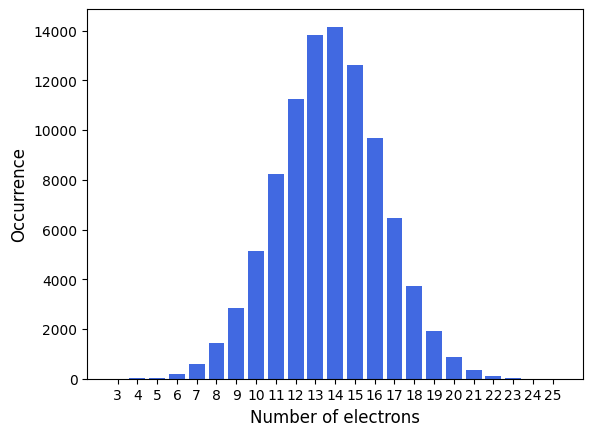

In [10]:
from collections import Counter
import matplotlib.pyplot as plt

# Compute Hamming weights
hamming_weights = [key.count('1') for key in counts_hw.keys()]

# Count occurrences of each Hamming weight
hammingw_counts = Counter(hamming_weights)

# Sort by most to least frequent
sorted_hammingw = dict(sorted(hammingw_counts.items(), key=lambda x: x[1], reverse=True))

# Print results
for weight, count in sorted_hammingw.items():
    print(f"Number of elelctrons (hamming weight): {weight}, Count: {count}")

# Plot results
x_values = sorted(hammingw_counts.keys(), reverse=True)  
y_values = [hammingw_counts[x] for x in x_values]
plt.bar(x_values, y_values, color='royalblue')
plt.xlabel("Number of electrons", fontsize=12)
plt.ylabel("Occurrence", fontsize=12)
x_labels = list(x_values)
plt.xticks(x_labels)
plt.show()

Now let's see how many of the bistrings with the correct number of electrons also have the correct number of electrons for each spin (7 alpha+7 beta since we are considering a spin singlet).

In [11]:
correct_bitstrings = {}

midpoint = n_qbits // 2
num_elec_a = num_elec_b = int(nelec/2)
for bitstring, value in counts_hw.items():
    first_half = bitstring[:midpoint]
    second_half = bitstring[midpoint:]

    if first_half.count("1") == num_elec_b and second_half.count("1") == num_elec_a:
       correct_bitstrings[bitstring] = 1 # Since the number of occurences is not important herem we simply use the value 1

print(f"{len(correct_bitstrings)} out of {sorted_hammingw[nelec]} bitstrings with {nelec} electrons have the correct number of electrons for each spin.")

5485 out of 14159 bitstrings with 14 electrons have the correct number of electrons for each spin.


### Diagonalization in the subspace of the "correct" bitstrings

It is interesting to see the results that can be obtained before configuration recovery. Only the configurations with the correct number of electrons and spin should be included.

In [12]:
from qiskit_addon_sqd.fermion import solve_fermion

bitstring_matrix_cb, _ = counts_to_arrays(correct_bitstrings)
energy_cb, _, _, spin_sq = solve_fermion(bitstring_matrix_cb, H1, H2)
print(
    "###########################################################################\n"
    f"Ground state energy approximation: {energy_cb}\n"
    "###########################################################################"
)
print(f"Deviation of SQD (hardware experiment before configuration recovery) from reference FCI: {energy_cb-E_FCI} Ha")
print(f"Spin squared {spin_sq}")

###########################################################################
Ground state energy approximation: -74.67645318097723
###########################################################################
Deviation of SQD (hardware experiment before configuration recovery) from reference FCI: 0.029533345281478773 Ha
Spin squared 0.12423089134774246


### Configuration recovery

In [13]:
from qiskit_addon_sqd.fermion import solve_fermion
from qiskit_addon_sqd.subsampling import postselect_and_subsample
from qiskit_addon_sqd.fermion import flip_orbital_occupancies
from qiskit_addon_sqd.configuration_recovery import recover_configurations

# SQD options
iterations = 5
rand_seed = 42

# Eigenstate solver options
n_batches = 1
samples_per_batch = nshots_hw
max_davidson_cycles = 200

num_elec_a = num_elec_b = int(nelec/2)
num_orbitals = int(n_qbits/2)

energy_hist = np.zeros((iterations, n_batches))  # energy history
occupancy_hist = np.zeros((iterations, 2 * num_orbitals))
occupancies_bitwise = None  # orbital i corresponds to column i in bitstring matrix

for i in range(iterations):
    print(f"Starting configuration recovery iteration {i}")
    # On the first iteration, we have no orbital occupancy information from the
    # solver, so we just post-select from the full bitstring set based on hamming weight.
    if occupancies_bitwise is None:
        bs_mat_tmp = bitstring_matrix_hw
        probs_arr_tmp = probs_arr_hw

    # If we have average orbital occupancy information, we use it to refine the full set of noisy configurations
    else:
        bs_mat_tmp, probs_arr_tmp = recover_configurations(
            bitstring_matrix_hw,
            probs_arr_hw,
            occupancies_bitwise,
            num_elec_a,
            num_elec_b,
            rand_seed=rand_seed,
        )

    # Throw out configurations with incorrect particle number in either the spin-up or spin-down systems
    batches = postselect_and_subsample(
        bs_mat_tmp,
        probs_arr_tmp,
        hamming_right=num_elec_a,
        hamming_left=num_elec_b,
        samples_per_batch=samples_per_batch,
        num_batches=n_batches,
        rand_seed=rand_seed,
    )

    # Run eigenstate solvers in a loop. This loop should be parallelized for larger problems.
    energy_tmp = np.zeros(n_batches)
    occs_tmp = np.zeros((n_batches, 2 * num_orbitals))
    for j in range(n_batches):
        energy_sci, _, avg_occs, spin_sq = solve_fermion(
            batches[j],
            H1,
            H2,
        )
        print(f"Spin squared {spin_sq}")
        energy_sci += H0
        energy_tmp[j] = energy_sci
        occs_tmp[j, :num_orbitals] = avg_occs[0]
        occs_tmp[j, num_orbitals:] = avg_occs[1]

    # Combine batch results
    avg_occupancies = np.mean(occs_tmp, axis=0)
    # The occupancies from the solver should be flipped to match the bits in the bitstring matrix.
    occupancies_bitwise = flip_orbital_occupancies(avg_occupancies)

    # Track optimization history
    energy_hist[i, :] = energy_tmp
    occupancy_hist[i, :] = avg_occupancies

min_e = np.min(energy_hist) # Submit this value
print(
    "###########################################################################\n"
    f"Ground state energy approximation: {min_e}\n"
    "###########################################################################"
)

#plot_histogram(counts)

Starting configuration recovery iteration 0
Spin squared 0.12423089134774246
Starting configuration recovery iteration 1
Spin squared 0.00017094659802891778
Starting configuration recovery iteration 2
Spin squared 0.0001483681541959953
Starting configuration recovery iteration 3
Spin squared 0.0001494872592297457
Starting configuration recovery iteration 4
Spin squared 0.0001494872592297457
###########################################################################
Ground state energy approximation: -74.70588130873729
###########################################################################


In [14]:
print(f"Deviation of SQD (hardware experiment) from reference FCI: {min_e-E_FCI} Ha")

Deviation of SQD (hardware experiment) from reference FCI: 0.0001052175214226736 Ha
